<a href="https://colab.research.google.com/github/odemircse/NetworkAnalysis/blob/main/word_cloud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install necessary libraries
!pip install -q spacy pyvis wordcloud

# Download the large English language model from spaCy (needed for good word vectors)
!python -m spacy download en_core_web_lg
from google.colab import files

# This will prompt you to upload a file from your computer
uploaded = files.upload()

# Print the names of the uploaded files
for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB ? eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Saving 03.a. MEB K-12. EN (1).txt to 03.a. MEB K-12. EN (1) (2).txt
User uploaded file "03.a. MEB K-12. EN (1) (2).txt" with length 311177 bytes


              Word  Count
0               ai   1295
1        education    674
2          teacher    462
3          student    461
4       technology    420
5              use    402
6             data    268
7         training    254
8           system    248
9          process    247
10        learning    244
11            tool    201
12     application    193
13         content    163
14     development    136
15        language    134
16        solution    118
17            need    116
18           skill    109
19      assessment    102
20       principle     98
21     information     97
22  implementation     97
23       awareness     95
24        security     94
25          policy     93
26      evaluation     92
27         program     90
28     participant     87
29          school     87
30        proposal     86
31            area     76
32         project     76
33        strategy     75
34      experience     75
35        ministry     75
36     environment     74
37          

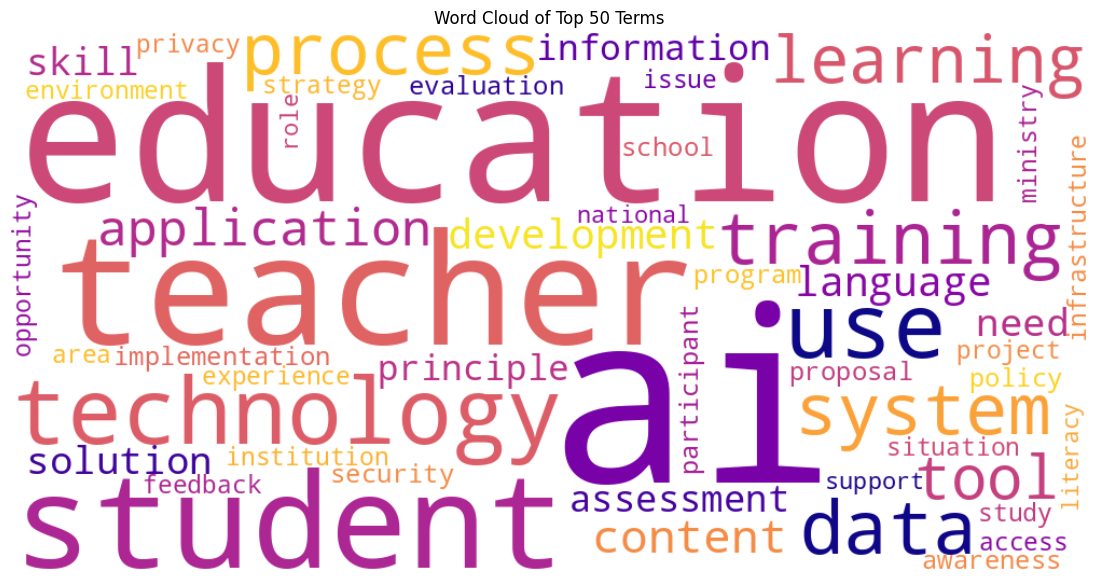

[]


In [ ]:

import spacy
from spacy.matcher import PhraseMatcher
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd


# 1. Load spaCy model
nlp = spacy.load("en_core_web_lg")

# The path to the text file
file_path = "/content/03.a. MEB K-12. EN (1).txt"

# Read the text from the file
try:
    # Try reading with latin-1 encoding first
    with open(file_path, 'r', encoding='latin-1') as f:
        text = f.read()
except UnicodeDecodeError:
    # If latin-1 fails, try another common encoding like cp1252
    try:
        with open(file_path, 'r', encoding='cp1252') as f:
            text = f.read()
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found. Please run Cell 2 or 3 first.")
        text = ""
    except Exception as e:
        print(f"An unexpected error occurred while reading the file with cp1252: {e}")
        text = ""
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please run Cell 2 or 3 first.")
    text = ""
except Exception as e:
    print(f"An unexpected error occurred while reading the file with latin-1: {e}")
    text = ""

# 🧼 Temizlik filtresi
import unicodedata
import re

# 1. Hedefli düzeltme
text = text.replace("studentsõ", "students")

# 2. Yaygın bozuk karakter düzeltmeleri
replacements = {
    "õ": "'", "â€™": "'", "â€“": "-", "â€œ": '"', "â€": '"',
    "Ã¶": "ö", "Ã¼": "ü", "Ã§": "ç", "ÅŸ": "ş", "Ä±": "ı",
    "Ã‡": "Ç", "Ä°": "İ", "Åž": "Ş", "Ã–": "Ö", "Ãœ": "Ü", "Ã": "a"
}
for wrong, correct in replacements.items():
    text = text.replace(wrong, correct)

# 3. Unicode normalize
text = unicodedata.normalize("NFC", text)

# 4. Garip karakterli kelimeleri temizle
text = ' '.join([
    word for word in text.split()
    if all((ord(c) < 128 or c in 'çÇğĞöÖşŞüÜıİ') for c in word)
])

# 5. Fazla boşlukları temizle
text = re.sub(r'\s+', ' ', text).strip()

#Initialize doc
if text:
  doc = nlp(text)

# 2. Concept map for grouping
concept_map = {
    "learning & teaching": ["Learning & Teaching", "Teaching & Learning", "learning and teaching", "teaching and learning"],
    "data": ["Datum", "Data"],
    "higher education": ["Higher Education", "University"],
    "critical thinking":["Critical Thinking"],
    "cognitive skills": ["Cognitive Skills"],
    "research and development": ["Research and Development","r&d"],
    "competency": ["Competence Framework"],
    "high school":["High School"],
    "generative ai":["generative ai"]
}


# 3. Build matcher
matcher = PhraseMatcher(nlp.vocab, attr="LOWER")
for label, phrases in concept_map.items():
    patterns = [nlp.make_doc(phrase) for phrase in phrases]
    matcher.add(label, patterns)


# 4. Merge matches into single tokens with normalized lemmas
matches = matcher(doc)
spans = [doc[start:end] for _, start, end in matches]
with doc.retokenize() as retokenizer:
    for span in spans:
        label = next((key for key, val in concept_map.items() if span.text.lower() in [v.lower() for v in val]), None)
        if label:
            retokenizer.merge(span, attrs={"LEMMA": label})

# 5. Extract nouns and proper nouns, exclude stopwords/punctuations
excluded_words = {
        "develop", "create", "provide", "ensure", "prepare", "establish", "provide", "prepare", "determine", "learn", "develop", "apply", "educate", "communicate"
    }
filtered_words = [
    token.lemma_.lower()
    for token in doc
    if not token.is_stop
    and not token.is_punct
    and not token.is_space
    and token.pos_ in {"NOUN", "PROPN"}
    and token.lemma_.lower() not in excluded_words
]

# 6. Get top 50 frequent terms
word_counts = Counter(filtered_words)
most_common = word_counts.most_common(50)
df = pd.DataFrame(most_common, columns=["Word", "Count"])
print(df)

# 7. Generate word cloud  - Burada colormap için viridis yerine turbo,rocket, plasma, magma kullanılabilir
wc = WordCloud(width=1000, height=500, background_color="white", colormap="plasma")
wc.generate_from_frequencies(dict(most_common))

plt.figure(figsize=(15, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Top 50 Terms")
plt.show()

from collections import Counter
words = text.split()
weird_words = [word for word in words if any(ord(c) > 127 for c in word)]
print(Counter(weird_words).most_common(10))
